# 00 · Foundations — the words the cookbook assumes

This is the notebook that comes **before** everything else. It builds the core
vocabulary — potential outcomes, counterfactuals, confounding, randomization,
identification, the do-operator, DAGs, and ATE vs CATE — from nothing, using one
marketing example, and ends with a tiny **end-to-end** demonstration: confounding
biases a naive answer, and the right adjustment fixes it.

No new theory here — it mirrors `docs/causal_inference_primer.pdf`. Skim it once and
every later notebook reads as a *named tool* rather than new vocabulary.


In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from cmp import plots
plots.use_style()
rng = np.random.default_rng(0)

## 1 · Treatment, unit, outcome — and the counterfactual

A **treatment** is any action whose effect we want to measure (send a discount,
show an ad, change a price). The **unit** receives it (a customer, store, region);
the **outcome** is what we measure after (spend, retention).

For a binary treatment $T\in\{0,1\}$ each unit has **two potential outcomes**:
$Y(1)$ if treated, $Y(0)$ if not. We only ever observe **one** —
$Y = T\,Y(1) + (1-T)\,Y(0)$ — so the individual effect $Y(1)-Y(0)$ is never
directly seen. This is the **fundamental problem of causal inference**: it is a
*missing-data* problem, and everything downstream is principled imputation of the
half of the table we didn't get to see.


In [2]:
# Anna's two potential outcomes — we only ever see one of them.
demo = pd.DataFrame({
    "customer": ["Anna", "Ben", "Cara"],
    "Y(0) if NOT emailed": [30, 55, 20],
    "Y(1) if emailed":     [80, 60, 22],
})
demo["true individual effect"] = demo["Y(1) if emailed"] - demo["Y(0) if NOT emailed"]
demo["we email?"] = ["yes", "no", "yes"]
demo["→ we OBSERVE"] = [80, 55, 22]      # the branch matching the treatment given
demo

,customer,Y(0) if NOT emailed,Y(1) if emailed,true individual effect,we email?,→ we OBSERVE
0,Anna,30,80,50,yes,80
1,Ben,55,60,5,no,55
2,Cara,20,22,2,yes,22


## 2 · From individuals to averages, and the enemy: confounding

Business decisions run on **averages**, not Anna's private branch. The headline is
the **Average Treatment Effect** $\text{ATE}=\mathbb{E}[Y(1)-Y(0)]$. The whole
difficulty collapses onto one word — **comparable**: to estimate $\mathbb{E}[Y(0)]$
for the treated, we need a control group that is *like them in every way except the
treatment*.

**Confounding** is what breaks comparability. If we email our *loyal* customers and
compare to *casual* controls, loyal customers spend more anyway — "loyalty" drove
both who got emailed and how much they spend. A **confounder** is a common cause of
treatment and outcome, and the naive "treated − control" difference silently blames
the treatment for a difference that was really about *who ended up in each group*.


## 3 · The gold standard, and life without it

**Randomization** (an A/B test) annihilates confounding by design: a coin flip makes
treatment independent of every confounder, measured or not, so
$\text{ATE}=\langle Y\mid T=1\rangle-\langle Y\mid T=0\rangle$ — a plain difference
of means.

When we *can't* randomize (the treatment already happened, observationally), we must
**identify** the effect using assumptions:

1. **Unconfoundedness** $\{Y(0),Y(1)\}\perp T\mid X$ — within units that look alike
   on measured $X$, who got treated is as-good-as-random. *(The big, untestable one.)*
2. **Positivity / overlap** $0<e(x)<1$ where $e(x)=P(T{=}1\mid X{=}x)$ is the
   **propensity score** — every kind of unit could have gone either way.
3. **SUTVA** — no interference, one version of treatment.

Under these, the **adjustment (g-)formula** compares like-with-like *within* strata
of $X$ and averages back up:
$\text{ATE}=\mathbb{E}_X\!\left[\mathbb{E}[Y\mid T{=}1,X]-\mathbb{E}[Y\mid T{=}0,X]\right].$


## 4 · Seeing vs doing (the do-operator), DAGs, colliders

There is a difference between **observing** $X=x$ (units where $X$ happened to be $x$,
carrying all the reasons it got there) and **doing** $do(X=x)$ (reaching in and
*setting* it, overriding those reasons). Causal effects are about *doing*:
$\mathbb{E}[Y\mid do(T{=}1)]-\mathbb{E}[Y\mid do(T{=}0)]$.

A **DAG** draws each variable as a node and each direct cause as an arrow. It tells
you exactly what to control for:

- **Backdoor path** — a path from $T$ to $Y$ that starts with an arrow *into* $T$
  (e.g. $T\leftarrow \text{loyalty}\rightarrow Y$). Block it by conditioning on a
  variable on it. The minimal blocking set is the $X$ in the adjustment formula.
- **Mediator** — if $T\to M\to Y$, controlling for $M$ removes part of the effect
  you want. *Don't adjust for things the treatment causes.*
- **Collider** — $T\to C\leftarrow Y$. Conditioning on $C$ *opens* a path and
  manufactures a spurious association ("explaining away"). *Never control for a
  post-treatment collider* (e.g. "opened the email").


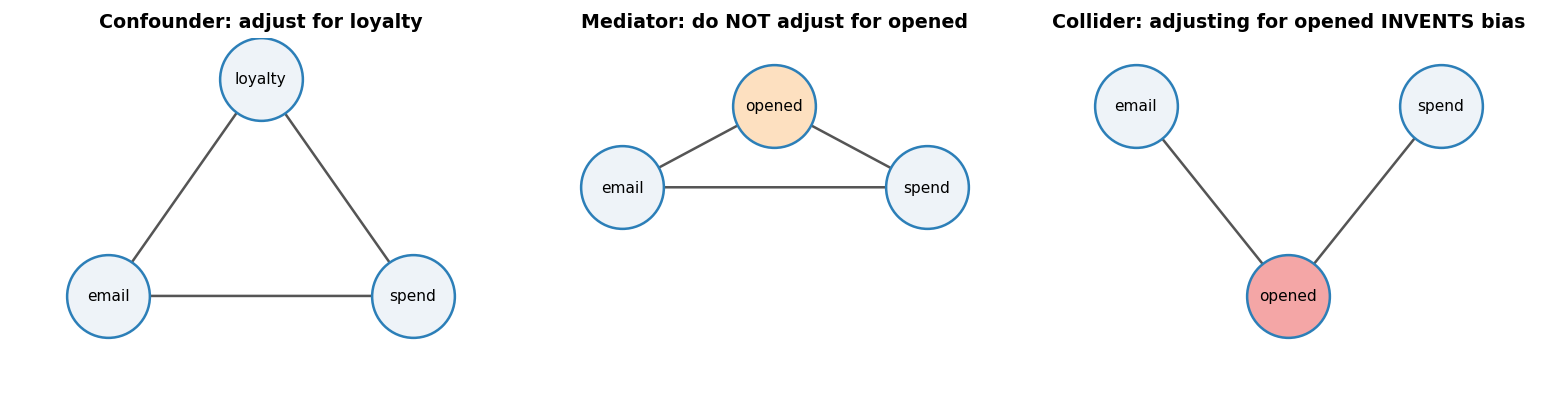

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))
# confounder
plots.draw_dag(ax[0], {"loyalty": (0.5, 1.0), "email": (0.1, 0.2), "spend": (0.9, 0.2)},
               [("loyalty","email"),("loyalty","spend"),("email","spend")],
               title="Confounder: adjust for loyalty")
# mediator
plots.draw_dag(ax[1], {"email": (0.1, 0.6), "opened": (0.5, 0.9), "spend": (0.9, 0.6)},
               [("email","opened"),("opened","spend"),("email","spend")],
               node_colors={"opened":"#fde0c0"},
               title="Mediator: do NOT adjust for opened")
# collider
plots.draw_dag(ax[2], {"email": (0.1, 0.9), "spend": (0.9, 0.9), "opened": (0.5, 0.2)},
               [("email","opened"),("spend","opened")],
               node_colors={"opened":"#f4a6a6"},
               title="Collider: adjusting for opened INVENTS bias")
fig.tight_layout()

## 5 · One effect for everyone, or a different effect for each?

- **ATE** — one number for the population ("did the program lift revenue overall?").
  This is **program evaluation / incrementality** (notebooks 06–11).
- **CATE** — the effect as a function of who you look at,
  $\tau(x)=\mathbb{E}[Y(1)-Y(0)\mid X{=}x]$. This is **heterogeneous treatment
  effects (HTE)** — the centre of the uplift/targeting story (notebooks 01–04).

Why HTE is the whole game for targeting: if the effect were identical for everyone,
there'd be no one to select — you'd rationally treat all or none. It's precisely
because $\tau(x)$ *varies* that you can spend only on the customers it works on.

*(One more term: sometimes a method only recovers the effect for a sub-population —
e.g. the compliers an instrument nudges. That restricted quantity is a **LATE**;
notebook 11.)*


## 6 · Where the Bayesian machinery enters

Identification is an argument about the world; **estimation** is the statistics you
do once you've granted it. Put a model with parameters $\theta$ on the response
surface $\mu_t(x;\theta)=\mathbb{E}[Y\mid T{=}t,X{=}x;\theta]$. Every estimand (ATE,
$\tau(x)$) is a deterministic **functional of $\theta$**, so the posterior
$p(\theta\mid\text{data})$ pushes forward into a **posterior on the effect itself** —
a credible interval falls out for free, no bootstrap. Throughout this repo that
interval is narrated as *"how sure are we, and does it change what we'd do?"*

> The discipline: **Bayes sharpens estimation, never identification.** A tight,
> beautiful posterior computed under a false unconfoundedness assumption is
> *confidently wrong*. Priors don't fix broken causal arguments — the graph does.


## 7 · Tiny end-to-end: confounding, and the fix

The loyalty story, in code. We simulate email **confounded by loyalty** (loyal
customers are both more likely to be emailed *and* spend more), with a known true
effect of **€5**. We then compare three answers:

1. **Naive** difference of means (ignores loyalty) — biased upward.
2. **Adjusted** — condition on loyalty (the correct backdoor set) — recovers €5,
   with a credible interval.
3. **Collider trap** — additionally "control for" `opened_email` (a post-treatment
   collider) — re-introduces bias. More controls is *not* safer.


In [4]:
from cmp import dgp
df, true_ate = dgp.dag_control_demo(n=1500, seed=17)
print(f"TRUE effect of email on spend = €{true_ate:.1f}")

naive = df.loc[df.email==1,'spend'].mean() - df.loc[df.email==0,'spend'].mean()

def ols_effect(data, controls):
    Xd = np.column_stack([np.ones(len(data)), data['email'].values]
                         + [data[c].values for c in controls])
    beta, *_ = np.linalg.lstsq(Xd, data['spend'].values, rcond=None)
    return beta[1]

adj_correct = ols_effect(df, ['loyalty'])                 # correct adjustment set
adj_collider = ols_effect(df, ['loyalty','opened_email']) # collider trap
print(f"1. naive (ignore loyalty)        €{naive:5.2f}   (biased)")
print(f"2. adjust for loyalty            €{adj_correct:5.2f}   (correct)")
print(f"3. also 'control' opened_email   €{adj_collider:5.2f}   (collider re-biases)")

TRUE effect of email on spend = €6.0
1. naive (ignore loyalty)        € 9.43   (biased)
2. adjust for loyalty            € 5.80   (correct)
3. also 'control' opened_email   € 5.12   (collider re-biases)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [b, sd]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 0 seconds.


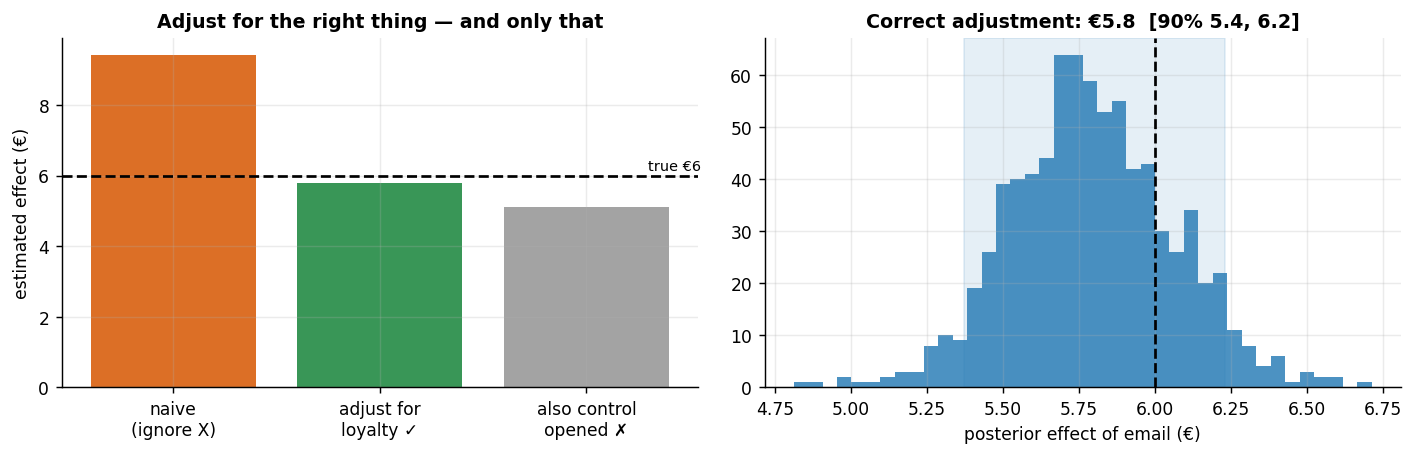

In [5]:
# The Bayesian version of (2): a posterior over the effect, interval for free.
import pymc as pm
with pm.Model() as m:
    b = pm.Normal("b", 0, 10, shape=3)          # intercept, email, loyalty
    sd = pm.HalfNormal("sd", 10)
    mu = b[0] + b[1]*df['email'].values + b[2]*df['loyalty'].values
    pm.Normal("y", mu=mu, sigma=sd, observed=df['spend'].values)
    idata = pm.sample(400, tune=400, chains=2, cores=2, random_seed=1,
                      progressbar=False, compute_convergence_checks=False)
post_effect = idata.posterior["b"].values[..., 1].ravel()
lo, hi = np.quantile(post_effect, [0.05, 0.95])

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
names = ["naive\n(ignore X)", "adjust for\nloyalty ✓", "also control\nopened ✗"]
ax[0].bar(names, [naive, adj_correct, adj_collider],
          color=[plots.ORANGE, plots.GREEN, plots.GREY], alpha=0.9)
ax[0].axhline(true_ate, color="k", ls="--"); ax[0].text(2.3, true_ate+0.15, f"true €{true_ate:.0f}", fontsize=8)
ax[0].set_ylabel("estimated effect (€)"); ax[0].set_title("Adjust for the right thing — and only that")
ax[1].hist(post_effect, bins=40, color=plots.BLUE, alpha=0.85)
ax[1].axvline(true_ate, color="k", ls="--"); ax[1].axvspan(lo, hi, color=plots.BLUE, alpha=0.12)
ax[1].set_xlabel("posterior effect of email (€)")
ax[1].set_title(f"Correct adjustment: €{post_effect.mean():.1f}  [90% {lo:.1f}, {hi:.1f}]")
fig.tight_layout()

### The eight words to walk in with

**Treatment** (the intervention) · **counterfactual / potential outcome** (the
branch you didn't observe) · **confounder** (common cause of treatment and outcome)
· **randomization** (kills confounding by design) · **identification** (the
assumptions that make an effect recoverable) · **do-operator** (forcing vs
observing) · **backdoor / collider** (what to control for, and what never to) ·
**ATE vs CATE** (one effect for all vs a different effect per customer).

**Next:** [01 · uplift targeting](01_uplift_targeting.ipynb) (Anchor A, HTE) and
[07 · geo-lift synthetic control](07_geo_lift_synthetic_control.ipynb) (Anchor B,
program evaluation) — then the rest of the cookbook.
